# Multi-Agent Researcher

This notebook demonstrates the multi-agent research approach, which uses a supervisor-researcher collaborative pattern to create comprehensive reports. The system consists of:

1. A **Supervisor Agent** that plans the overall report structure and coordinates work
2. Multiple **Research Agents** that investigate specific topics in parallel
3. A workflow that produces a structured report with introduction, body sections, and conclusion

## From repo 

In [1]:
from pathlib import Path
import os
import sys

repo_root = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(repo_root / "src")
sys.path.insert(0, str(repo_root / "src"))
%load_ext autoreload
%autoreload 2

In [2]:
# ! pip install -U -q -e ..

# Compile the multi-agent graph

Next, we'll compile the LangGraph workflow for the multi-agent research approach. This step creates the orchestration layer that manages communication between the supervisor and research agents.

In [3]:
import uuid 
import os, getpass
import open_deep_research   
# print(open_deep_research.__version__) 
from IPython.display import Image, display, Markdown
from langgraph.checkpoint.memory import MemorySaver
from legacy.multi_agent import supervisor_builder

In [8]:
# Create a MemorySaver for checkpointing the agent's state
# This enables tracking and debugging of the multi-agent interaction
checkpointer = MemorySaver()
agent = supervisor_builder.compile(
    name="research_team", 
    checkpointer=checkpointer
    )

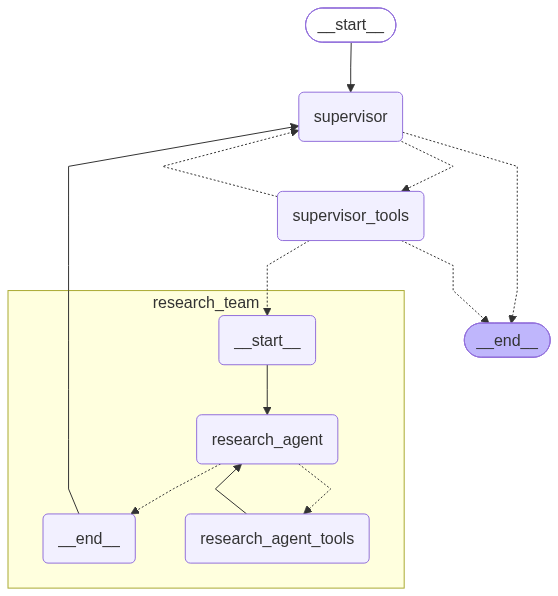

In [5]:
# Visualize the graph structure
# This shows how supervisor and research agents are connected in the workflow
display(Image(agent.get_graph(xray=1).draw_mermaid_png(max_retries=5)))

In [9]:
research_topic = "What is model context protocol?"
# Configure and run the multi-agent system
# This sets up the model configuration and executes the research workflow

# Configure models and search API for both supervisor and researcher roles
config = {
    "thread_id": str(uuid.uuid4()),
    "search_api": "tavily",
    "supervisor_model": "google_genai:gemini-3.7-flash",
    "researcher_model": "google_genai:gemini-3.7-flash",
    }

# Set up thread configuration with the specified parameters
thread_config = {"configurable": config}

# Define the research topic as a user message
msg = [{
    "role": "user", 
    "content": research_topic,
    }]

# Run the multi-agent workflow with the specified configuration
response = await agent.ainvoke(
    {"messages": msg}, 
    config=thread_config)

In [10]:
messages = agent.get_state(thread_config).values['messages']
messages[-1].pretty_print()

Deserializing unregistered type legacy.multi_agent.Section from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('legacy.multi_agent', 'Section')]


================================ Human Message =================================

Report is Finish


In [11]:
msg =  [{
    "role": "user", 
    "content": "Focus on Anthropic‑backed open standard for integrating external context and tools with LLMs, give an architectural overview for developers, tell me about interesting MCP servers, compare to google Agent2Agent (A2A) protocol. write the report and dont ask any follow up questions"}]
response = await agent.ainvoke({"messages": msg}, config=thread_config)
for m in agent.get_state(thread_config).values['messages']:
    m.pretty_print()

================================ Human Message =================================

What is model context protocol?
================================== Ai Message ==================================

[]
Tool Calls:
  tavily_search (call_59569)
 Call ID: call_59569
  Args:
    queries: ['Model Context Protocol MCP Anthropic architecture overview', 'Model Context Protocol specification components clients servers resources tools prompts']
================================= Tool Message =================================
Name: tavily_search

Search results: 



--- SOURCE 1: Anthropic's Model Context Protocol (MCP): A Deep Dive for ... ---
URL: https://medium.com/@amanatulla1606/anthropics-model-context-protocol-mcp-a-deep-dive-for-developers-1d3db39c9fdc

SUMMARY:
## Under the Hood: MCP Architecture Explained

The Model Context Protocol (MCP) is built on a flexible and extensible architecture that facilitates seamless communication between LLM applications and various integrations . At its core

In [12]:
from IPython.display import Markdown
Markdown(agent.get_state(thread_config).values['final_report'])

# Understanding the Model Context Protocol (MCP)

As large language models (LLMs) and autonomous agents become central to modern software engineering and enterprise workflows, their utility remains fundamentally constrained by isolation from external data and runtime environments. Traditionally, connecting foundation models to external APIs, databases, file repositories, and development tools required fragmented, bespoke connectors—creating a complex $N \times M$ integration problem across disparate AI models and external services.

Introduced by Anthropic in late 2024 and subsequently transitioned into an open industry standard governed under the Linux Foundation’s Agentic AI Foundation (AAIF), the **Model Context Protocol (MCP)** provides a universal, standardized communication layer between AI applications and external environments. Drawing architectural inspiration from the Language Server Protocol (LSP), MCP replaces proprietary plugins and hardcoded integrations with an open client-server architecture running over JSON-RPC 2.0. By standardizing how context is supplied, tools are discovered, and workflows are scaffolded, MCP enables plug-and-play interoperability across frontier models, developer environments, and enterprise platforms. This report explores the core architecture, primitives, comparative positioning, and security considerations defining the Model Context Protocol ecosystem.

## Core Architecture and Protocol Mechanics

The Model Context Protocol (MCP) organizes AI integration through a structured host-client-server architecture built on a two-layer design:

- **Host-Client-Server Topology**: The MCP host (e.g., IDE or desktop runtime) coordinates multiple isolated MCP clients. Each client maintains a dedicated 1:1 connection with an MCP server wrapping external data sources or tools.
- **Transport Layer**: Abstracts communication across local Standard Input/Output (`stdio`) for OS-sandboxed subprocesses, and Streamable HTTP (with SSE) or WebSockets for remote services.
- **Data Layer (JSON-RPC 2.0)**: Uses standardized JSON-RPC 2.0 framing for bidirectional, message-driven exchanges comprising requests, responses, and notifications.
- **Core Primitives**:
  - **Tools**: Model-controlled executable functions (`tools/call`) validated by JSON Schema.
  - **Resources**: Application-controlled, read-only context streams (`resources/read`).
  - **Prompts**: User- or template-driven interaction scaffolds (`prompts/get`).
- **Protocol Mechanics**: Sessions follow a lifecycle of capability discovery and version negotiation (`initialize` / `server/discover`), dynamic listing (`*/list`), execution, and asynchronous change notifications (`subscriptions/listen`).

### Sources
1. https://modelcontextprotocol.io/docs/2026-07-28/learn/architecture
2. https://pradeepl.com/blog/model-context-protocol/mcp-protocol-mechanics-and-architecture
3. https://www.databricks.com/blog/what-is-model-context-protocol

## Key Protocol Primitives: Tools, Resources, and Prompts

The Model Context Protocol (MCP) organizes server capabilities across three core primitives, each governed by a distinct control plane:

* **Tools (Model-Controlled):** Executable functions that enable language models to perform actions with real-world side effects (e.g., API requests, database writes). Discovered via `tools/list` and invoked via `tools/call`, tools accept JSON Schema arguments and typically require user authorization.
* **Resources (Application-Controlled):** Read-only data sources identified by unique URIs (`resources/read`). Managed and injected by host applications, resources provide passive contextual data—such as schemas, documents, or logs—without side-effect risks.
* **Prompts (User-Controlled):** Reusable, parameterized conversation templates surfaced directly to users via UI commands (`prompts/get`). Prompts guide LLM behavior, standardize complex workflows, and enforce consistent output structures across interactions.

By decoupling execution (tools), context (resources), and workflows (prompts), MCP establishes a clean, interoperable architecture for AI integrations.

### Sources
1. https://modelcontextprotocol.io/specification/2026-07-28
2. https://gingerlabs.ai/blog/mcp-tools-resources-prompts
3. https://dev.to/aws-heroes/mcp-prompts-and-resources-the-primitives-youre-not-using-3oo1

## Comparative Analysis: MCP vs. Function Calling and RAG

While frequently conflated, **Retrieval-Augmented Generation (RAG)**, **Function Calling**, and the **Model Context Protocol (MCP)** operate at distinct architectural layers:

* **RAG (Knowledge Layer):** Solves the information retrieval problem. It searches static, unstructured document stores via vector embeddings and injects relevant chunks into the context window before generation. It is read-only and lacks execution or action capabilities.
* **Function Calling (Execution Mechanism):** Solves the structured output problem. It allows LLMs to extract parameters and emit structured JSON to invoke predefined APIs. However, it is vendor-specific, tightly coupled, and lacks discovery mechanisms.
* **MCP (Integration Protocol):** Solves the system interoperability and control problem. An open, client-server standard, MCP decouples external capabilities from LLMs, enabling runtime tool discovery, structured resource access, and centralized enterprise governance (RBAC, auditing).

### Key Architectural Differences
* **Scope:** RAG retrieves static knowledge; Function Calling executes discrete actions; MCP manages dynamic context, resources, and tool orchestration.
* **Modularity:** Function calling requires provider-specific implementations, whereas MCP establishes a universal, reusable connection layer across multiple models and hosts.

Rather than competing, they form a complementary pipeline where RAG grounds knowledge, MCP governs connectivity, and function calling executes actions.

### Sources
1. https://www.mikaeels.com/blog/mcp-vs-rag-vs-function-calling
2. https://obot.ai/resources/learning-center/mcp-vs-function-calling
3. https://www.truefoundry.com/blog/mcp-vs-rag

## Ecosystem Adoption, Security Considerations, and Governance

The enterprise AI landscape has rapidly shifted from static language models to autonomous multi-agent ecosystems. The widespread adoption of open standards like the Model Context Protocol (MCP)—governed under the Linux Foundation's Agentic AI Foundation—enables seamless connectivity across tools, databases, and external APIs. However, this composability introduces critical security and governance challenges:

* **Expanding Attack Surfaces:** Dynamic tool invocation exposes environments to indirect prompt injection, tool schema poisoning, supply chain vulnerabilities from unvetted community servers, and cross-system data exfiltration.
* **Identity and Access Deficits:** Autonomous agents often operate with excessive ambient authority. The absence of strict per-user authentication and role-based permissions risks unauthorized data access and session hijacking.
* **Governance and Observability:** Organizations require end-to-end oversight to prevent "Shadow Agent" proliferation. Mitigations demand centralized agent registries, containerized sandboxing, runtime policy enforcement, and alignment with emerging frameworks like the OWASP Agentic Top 10 and Cloud Security Alliance AI Controls Matrix (AICM).

Securing agentic ecosystems requires moving beyond static code analysis to real-time behavioral guardrails, least-privilege delegation, and comprehensive audit telemetry.

### Sources
1. https://www.paloaltonetworks.com/cyberpedia/what-is-model-context-protocol-mcp
2. https://media.defense.gov/2026/Jun/02/2003943289/-1/-1/0/CSI_MCP_SECURITY.PDF
3. https://arxiv.org/html/2511.20920v1
4. https://labs.cloudsecurityalliance.org/research/csa-research-note-ai-agent-governance-framework-gap-20260403

## Conclusion and Future Outlook

The Model Context Protocol represents a paradigm shift in the architecture of generative AI and autonomous agent systems. By replacing bespoke, vendor-locked integration code with a generalized, open protocol, MCP resolves the combinatorial complexity of connecting heterogeneous models with arbitrary data sources and execution runtimes.

Through its distinct architectural separation of **Hosts**, **Clients**, and **Servers**, combined with well-defined primitives—**Tools**, **Resources**, and **Prompts**—MCP provides a cohesive framework for both passive context ingestion and active runtime computation. Rather than competing with foundational paradigms like Function Calling or Retrieval-Augmented Generation (RAG), MCP acts as an enabling transport and contract layer that unifies and standardizes how those techniques are consumed across ecosystems.

As major AI vendors (including Anthropic, OpenAI, and Google), developer tools (such as Claude Desktop, Cursor, and Zed), and enterprise platforms adopt MCP under the governance of the Agentic AI Foundation (AAIF), the protocol is positioned to serve as the definitive standard for context delivery and tool orchestration. Going forward, standardizing robust authentication (OAuth 2.1), granular permission models, and UI extensions (MCP Apps) will be vital in ensuring that agentic workflows remain both broadly capable and enterprise-secure.

Trace: 

> Note: uses 456k tokens 

https://smith.langchain.com/public/f1581fa5-dfc9-445c-a8f4-3518a05cd139/r